In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [3]:
df_one = pd.read_csv("One_Hot_claims_train.csv")
df_one

,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density,VehBrand_B1,VehBrand_B10,VehBrand_B11,...,Region_R53,Region_R54,Region_R72,Region_R73,Region_R74,Region_R82,Region_R83,Region_R91,Region_R93,Region_R94
0,0,0.43,7,18,36,95,1054,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0.10,7,17,80,95,598,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0.33,7,3,36,76,4172,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0,0.56,5,4,73,52,15,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0.27,8,0,37,50,3021,0,0,1,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541411,0,0.20,6,10,32,76,1314,0,0,0,...,0,0,0,0,0,0,0,0,0,0
541412,0,0.06,10,14,34,60,685,0,0,0,...,0,0,1,0,0,0,0,0,0,0
541413,0,0.34,6,8,32,95,242,0,0,0,...,0,0,0,0,0,1,0,0,0,0
541414,0,0.72,9,7,39,72,3301,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [9]:
scaler = StandardScaler()
pca = PCA(n_components=3)
X = df_one.loc[:, df_one.columns != 'ClaimNb']
X_scaled = scaler.fit_transform(X)
pca.fit(X_scaled)
X_pca = pca.transform(X_scaled)



In [18]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X_pca)
labels = kmeans.labels_  # cluster index for each row
centroids = kmeans.cluster_centers_

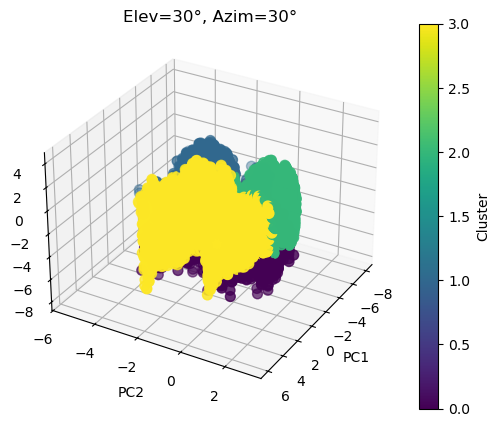

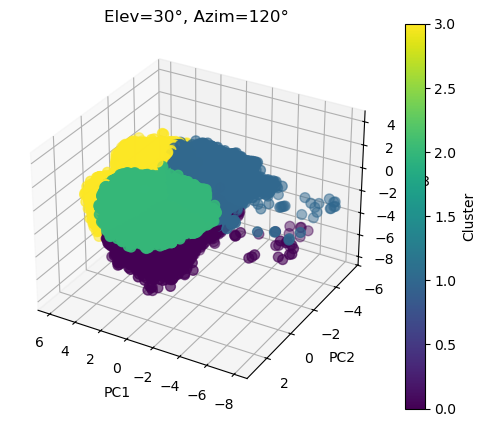

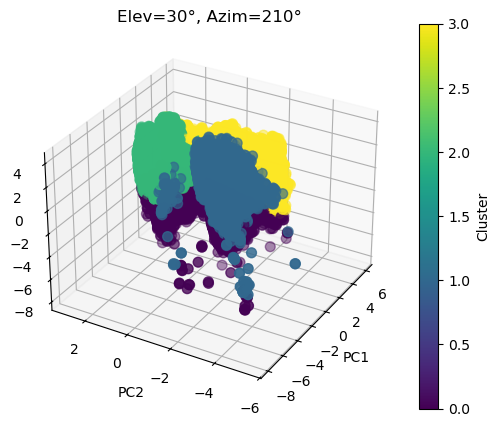

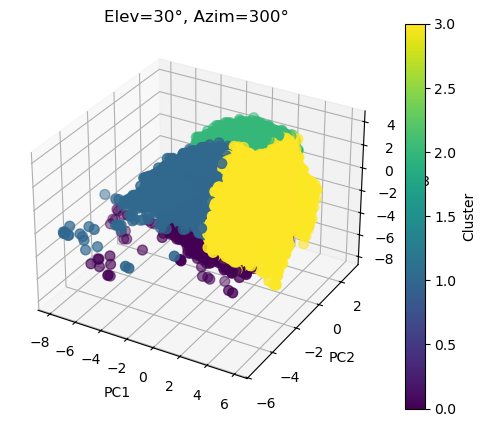

In [19]:
angles = [(30, 30), (30, 120), (30, 210), (30, 300)]  # (elevation, azimuth) pairs

for i, (elev, azim) in enumerate(angles):
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection='3d')
    
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
                         c=labels, cmap='viridis', s=50)
    
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    ax.view_init(elev=elev, azim=azim)  # set viewpoint
    
    plt.title(f'Elev={elev}°, Azim={azim}°')
    plt.colorbar(scatter, ax=ax, label='Cluster')
    plt.show()

In [20]:
scaler = StandardScaler()
pca = PCA(n_components=2)
X = df_one.loc[:, df_one.columns != 'ClaimNb']
X_scaled = scaler.fit_transform(X)
pca.fit(X_scaled)
X_pca = pca.transform(X_scaled)

In [24]:
k = 2
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X_pca)
labels = kmeans.labels_  # cluster index for each row
centroids = kmeans.cluster_centers_

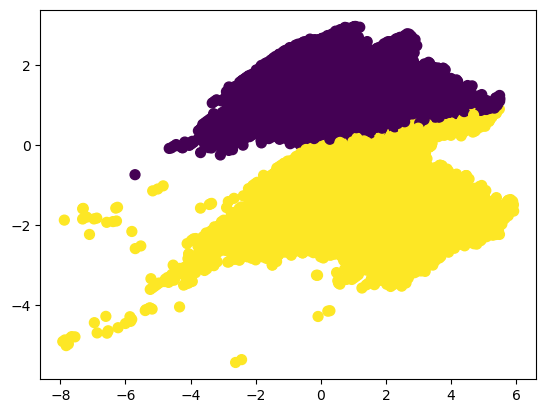

In [25]:
plt.scatter(X_pca[:,0],X_pca[:,1],c=labels, cmap='viridis', s=50)

Trying by droppped CSV

In [26]:
df_dropped = pd.read_csv("Dropped_claims_train.csv")
df_dropped

,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density
0,0,0.43,7,18,36,95,1054
1,0,0.10,7,17,80,95,598
2,0,0.33,7,3,36,76,4172
3,0,0.56,5,4,73,52,15
4,0,0.27,8,0,37,50,3021
...,...,...,...,...,...,...,...
541411,0,0.20,6,10,32,76,1314
541412,0,0.06,10,14,34,60,685
541413,0,0.34,6,8,32,95,242
541414,0,0.72,9,7,39,72,3301


In [27]:
scaler = StandardScaler()
pca = PCA(n_components=2)
X = df_dropped.loc[:, df_dropped.columns != 'ClaimNb']
X_scaled = scaler.fit_transform(X)
pca.fit(X_scaled)
X_pca = pca.transform(X_scaled)

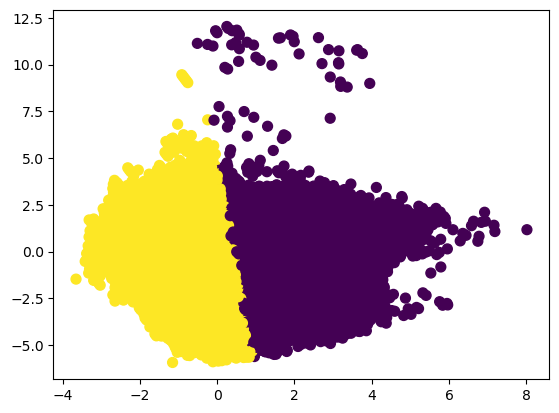

In [32]:
k = 2
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X_pca)
labels = kmeans.labels_  # cluster index for each row
centroids = kmeans.cluster_centers_
plt.scatter(X_pca[:,0],X_pca[:,1],c=labels, cmap='viridis', s=50)